# investalyze: data log (findings + decisions)

A running, reproducible record of data quirks (characteristics of the data itself) and the decisions
they drive. Each entry says what the quirk is, why it exists, and that it is genuine data, not a mistake.
One markdown cell + one code cell per entry, newest on top. Committed with outputs.

Status legend: ✅ understood · 🔶 open question · ❓ to verify

Entry template: header `## <ticker / topic>: <one-line>  <status>`, then **What:** and **Why:**.

## Index

- `^NDQ` / `^NDX` / `^SPX`: pre-inception histories are duplicated across tickers 🔶
- `^MRV` (Merval): index level spans ~8 orders of magnitude ✅

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helpers import connect_readonly, load_ticker_rows

con = connect_readonly()

## `^NDQ` / `^NDX` (and likely `^SPX`): pre-launch history is a scaled proxy of another ticker 🔶

**What**: `^NDQ` and `^NDX` hold a **constant price ratio** (~0.3979, std < 0.001) for their entire
shared history from 1938 up to 1985-10-02, then diverge to independent, uncorrelated real trading data
right around NASDAQ-100's actual October 1985 launch. `^SPX` shows the same exact-tie pattern against
`^NDQ` for some pre-1985 dates too. These are **genuine rows in the DB**, not a query bug: a
scale-invariant encoding (`rebase_to_100`) collapses matching pre-1985 windows to near-identical
vectors, an exact `sq_dist = 0.0` tie in a k-NN search.

**Why**: likely vendor backfilling, before the real index existed its history was proxied with a
scaled substitute (a fixed ratio to another series) rather than left absent.

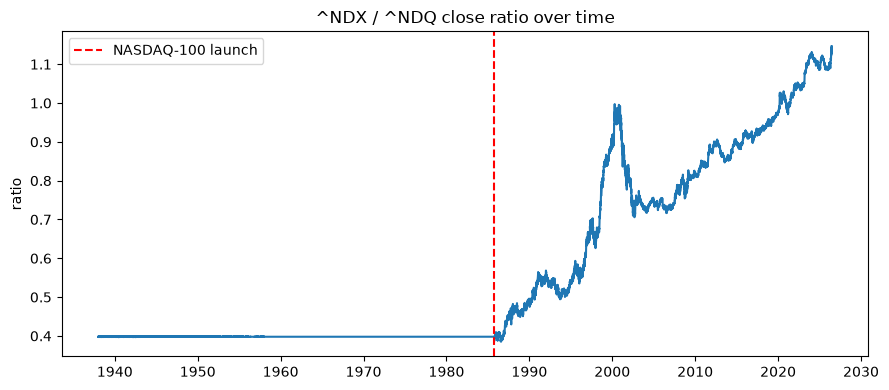

pre-launch  ratio: mean=0.3979 std=0.000222 (12585 rows)
post-launch ratio: mean=0.7755 std=0.201883 (10257 rows)


In [ ]:
a = load_ticker_rows(con, 'market_data', '^NDQ').sort_values('Date')
b = load_ticker_rows(con, 'market_data', '^NDX').sort_values('Date')
merged = a.merge(b, on='Date', suffixes=('_ndq', '_ndx'))
merged['ratio'] = merged['C_ndx'] / merged['C_ndq']

pre_launch = merged[merged['Date'] < '1985-10-02']
post_launch = merged[merged['Date'] >= '1985-10-02']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(merged['Date'], merged['ratio'])
ax.axvline(float(pd.Timestamp('1985-10-02')), color='red', ls='--', label='NASDAQ-100 launch')
ax.set_title('^NDX / ^NDQ close ratio over time')
ax.set_ylabel('ratio')
ax.legend()
plt.tight_layout()
plt.show()

pre_mean, pre_std = pre_launch['ratio'].mean(), pre_launch['ratio'].std()
post_mean, post_std = post_launch['ratio'].mean(), post_launch['ratio'].std()
print(f'pre-launch  ratio: mean={pre_mean:.4f} std={pre_std:.6f} ({len(pre_launch)} rows)')
print(f'post-launch ratio: mean={post_mean:.4f} std={post_std:.6f} ({len(post_launch)} rows)')

## `^MRV` (Merval, Argentina): index level spans ~8 orders of magnitude ✅

**What**: `^MRV`, the Argentine Merval index, has an enormous **dynamic range**: its nominal level runs
from ~0.03 (1988) to ~3.3M (2026), roughly **8 orders of magnitude**. This is **genuine data, not a feed
glitch**.

**Why**: decades of Argentine **hyperinflation** plus several **currency redenominations** inflate the
index.

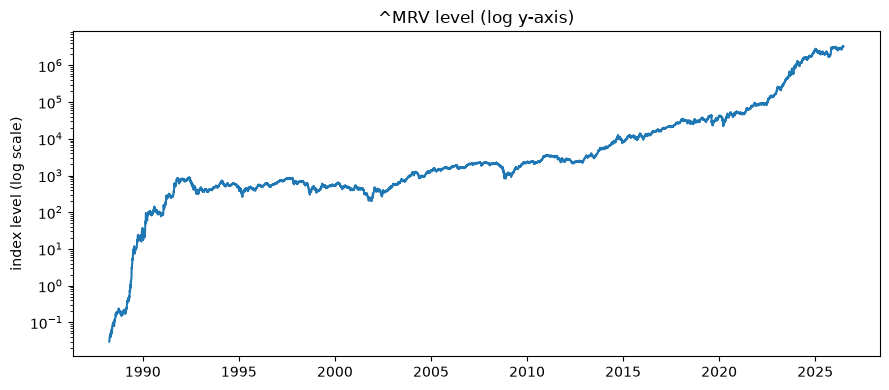

level range 0.03 to 3,353,008, span x111,766,925 (~8.0 orders of magnitude)


In [3]:
TICKER = '^MRV'

mrv = load_ticker_rows(con, 'market_data', TICKER).sort_values('Date')
price = mrv['C'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mrv['Date'], price)
ax.set_yscale('log')
ax.set_title(f'{TICKER} level (log y-axis)')
ax.set_ylabel('index level (log scale)')
plt.tight_layout()
plt.show()

span = price.max() / price.min()
print(f'level range {price.min():g} to {price.max():,.0f}, span x{span:,.0f} (~{np.log10(span):.1f} orders of magnitude)')

---